# FasterAI — Hands-on Model Compression Workshop

**TRAIL Factory Workshop** | June 23, 2026 · 12h00-16h00 | Le CLICK, Mons

Training a model is 1% of the journey. Shipping it — fast enough, small enough, cheap enough, on *your* hardware — is the other 99%. This workshop is about that 99%, using [FasterAI](https://github.com/FasterAI-Labs/fasterai) (compression) + FasterBench (measurement). Everything is open source.

The day is in **three parts**, each ending hands-on:

**Part 1: Measure.**

**Part 2: Compress**

**Part 3: Execute**

---

## ▶️ Setup — RUN THIS FIRST

Run the cell below **in order**.

### Install

In [1]:
# Colab: keep these 3 cells uncommented.
# Running locally with the repo already present: re-comment them.

In [2]:
# !git clone https://github.com/FasterAI-Labs/Workshop.git

In [3]:
# %cd Workshop/

In [4]:
#!pip install git+https://github.com/FasterAI-Labs/fasterai.git

In [ ]:
#!pip install git+https://github.com/FasterAI-Labs/fasterbench.git

### Import

In [5]:
from utils import *

print(f"CUDA available: {torch.cuda.is_available()}")

Skipping import of cpp extensions due to incompatible torch version 2.9.1+cu128 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info


CUDA available: True


---
# 🎯 ACT 1 — MEASURE
### *Find the bottleneck, before touching the model*

Before compressing anything, the first question to ask is **what makes the model slow ?**

## First question: does a FLOP count predict speed?

> 🔮 **Predict.** The cell below times two convolutions with the **exact same FLOP count**, same GPU, same precision. One is "fat" (many channels, small map), one is "thin" (few channels, big map). *Write down your guess: same time? If not, which is slower, and by how much?*

In [6]:
# Two convolutions with IDENTICAL FLOPs, same GPU, same precision.
# A "fat"  : many channels, small map     B "thin": few channels, big map
A = nn.Conv2d(256, 256, 3, padding=1).cuda().eval(); xA = torch.randn(1, 256, 32,   32,   device='cuda')
B = nn.Conv2d(8,   8,   3, padding=1).cuda().eval(); xB = torch.randn(1, 8,   1024, 1024, device='cuda')
flops = 2*A.out_channels*A.kernel_size[0]*A.kernel_size[1]*xA.numel()          # == 2*8*8*9*(1024*1024): identical

with torch.no_grad():
    tA, tB = benchm(lambda: A(xA)), benchm(lambda: B(xB))

print(f"Both convs do the SAME {flops/1e9:.2f} GFLOP\n")
print(f"A  (256ch, 32x32)  : {tA*1e3:6.2f} ms")
print(f"B  (8ch, 1024x1024): {tB*1e3:6.2f} ms")
print(f"\n--> Same FLOPs, but B is {tB/tA:.1f}x slower. Same GPU, same precision.")

Both convs do the SAME 1.21 GFLOP

A  (256ch, 32x32)  :   0.04 ms
B  (8ch, 1024x1024):   0.13 ms

--> Same FLOPs, but B is 3.3x slower. Same GPU, same precision.


## Why: two forces first — compute vs memory (the roofline)

The hook showed identical FLOPs, very different speed. The classic picture that explains it is the **roofline model**. A kernel's time is the larger of two costs:

```
time ≈ max( compute_cost , memory_cost ) = max( FLOPs / peak_FLOPs , bytes / bandwidth )
```

- many channels, dense math (the *fat* conv A) → compute is the bigger cost → **compute-bound**
- little math per byte, huge activations (the *thin* conv B) → moving data is the bigger cost → **memory-bound**

The roofline plots any kernel as a single point:

- **x = arithmetic intensity**, `AI = FLOPs / bytes_moved`  (FLOP/byte)
- **y = achieved performance**, `perf = FLOPs / measured_latency`  (FLOP/s) — the "speed in FLOPS"

and draws two ceilings: a **sloped memory roof** (`y = AI × bandwidth`) and a **flat compute roof** (`y = peak FLOP/s`), meeting at the **ridge point**:

```
ridge = peak_FLOPs / bandwidth        (FLOP/byte)
```

Left of the ridge a kernel is memory-bound; right of it, compute-bound.

## The third force: overhead (what the roofline can't show)

Look at the gap between where A and B actually landed and the roofs above them — especially B, which doesn't even reach its memory roof. The roofline says it *could* go faster on bandwidth alone, so where does the rest of the time go? Into the **third force the roofline has no axis for: overhead** — Python, kernel launches, dispatch, and under-utilisation when an op is too small to fill the GPU. It dominates at **batch = 1** and with many tiny ops.

In [7]:
def many_small_ops(t):
  for _ in range(30): t = torch.tanh(t) * 1.01 + 0.001
  return t

for C in [4, 8, 16, 64, 256, 1024, 4096]:
  x = torch.randn(1, C, 32, 32, device='cuda')
  print(f"{x.numel()*30*3/1e6:.2f} FLOPs, {x.numel()*4*30*3/1e6:.2f} KiB: {benchm(lambda: many_small_ops(x))*1e3:6.3f} ms")

0.37 FLOPs, 1.47 KiB:  0.236 ms
0.74 FLOPs, 2.95 KiB:  0.238 ms
1.47 FLOPs, 5.90 KiB:  0.239 ms
5.90 FLOPs, 23.59 KiB:  0.240 ms
23.59 FLOPs, 94.37 KiB:  0.239 ms
94.37 FLOPs, 377.49 KiB:  0.368 ms
377.49 FLOPs, 1509.95 KiB:  0.737 ms


While all those operations have the exact same AI (0.25), they behave completely differently (flat, then linear). That's overhead being invisible to the roofline: the roofline has only the AI axis, AI never moved, so it would plot all five on top of each other and couldn't tell the overhead-bound small ones from the memory-bound big ones.

You have now met all three forces:
- **compute** and **memory** — the two convs, same FLOPs, different speed;
- **overhead** — the fused chain, same math, big speedup.

Each compression technique attacks one or more of these forces. But before reaching for a technique, you have to know **which force is actually slowing *your* model on *your* hardware.**

---

# 🛠️ HANDS-ON #1 — Find the bottleneck

> 🎯 **Goal**: measure the per-layer AI and the speed profile of YOUR model on YOUR target, and see that the regime (memory/compute-bound) flips with the **hardware**, not with the model.

In [8]:
# 👉 CHANGE THIS to your target model.
model = resnet18()
#model = vgg16_bn()
#model = mobilenet_v2()

model.eval();

### Compute AI for each layer

In [9]:
# 👉 CHANGE THIS to your target image size.
IMAGE_SIZE = 128

layer_ai = compute_per_layer_ai(model, input_shape=(1, 3, IMAGE_SIZE, IMAGE_SIZE), n=20)

   # Layer                                                OPs           Bytes      AI (OPs/byte)
-----------------------------------------------------------------------------------------------
   0 conv1                                         77,070,336       1,282,816              60.08
   1 layer1.0.conv1                                75,497,472         671,744             112.39
   2 layer1.0.conv2                                75,497,472         671,744             112.39
   3 layer1.1.conv1                                75,497,472         671,744             112.39
   4 layer1.1.conv2                                75,497,472         671,744             112.39
   5 layer2.0.conv1                                37,748,736         688,128              54.86
   6 layer2.0.conv2                                75,497,472         851,968              88.62
   7 layer2.0.downsample.0                          4,194,304         425,984               9.85
   8 layer2.1.conv1            

In [10]:
TARGETS = {
    "t4-colab":    dict(label="NVIDIA T4 (this Colab)", peak_TFLOPs=8.1,  bw_GBs=320),
    "a100":        dict(label="NVIDIA A100",            peak_TFLOPs=312,  bw_GBs=2039),
    "jetson-orin": dict(label="Jetson Orin",            peak_TFLOPs=275,  bw_GBs=204),
    "x86-cpu":     dict(label="x86 CPU (AVX-512/VNNI)", peak_TFLOPs=1.5,  bw_GBs=80),
    "arm-mobile":  dict(label="ARM mobile (NEON)",      peak_TFLOPs=0.5,  bw_GBs=25),
}

# 👉 CHANGE THIS to your target hardware.
TARGET = TARGETS["x86-cpu"]

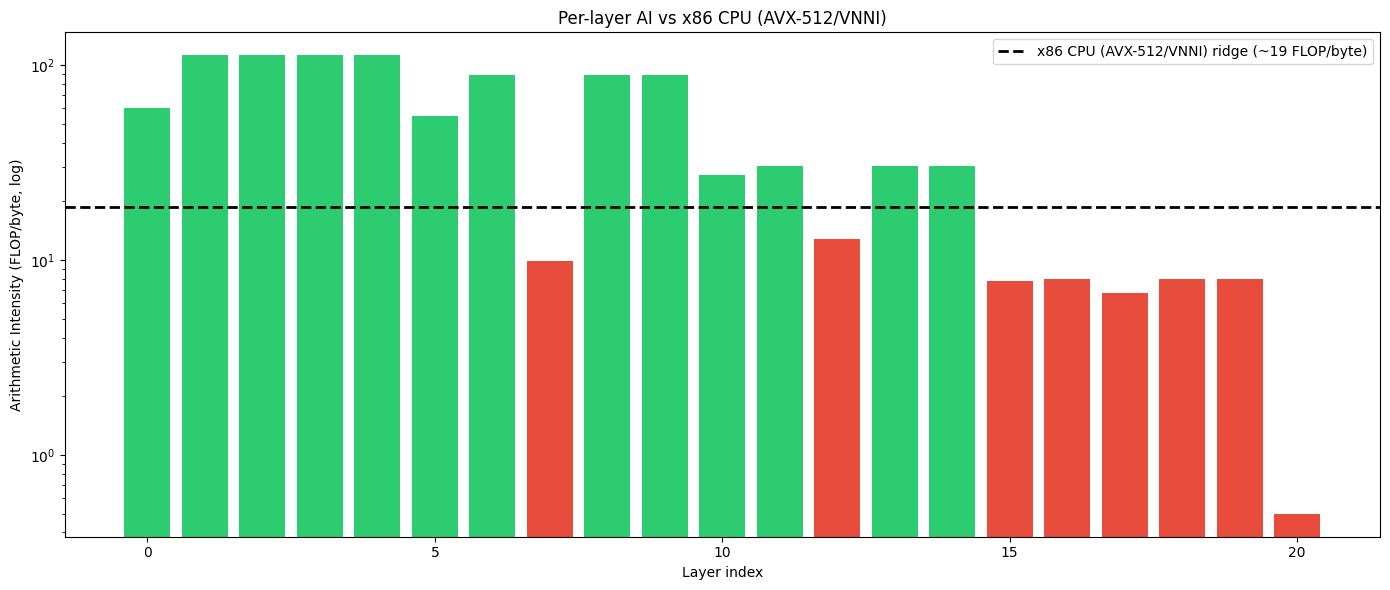

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Per-layer AI vs x86 CPU (AVX-512/VNNI)'}, xlabel='Layer index', ylabel='Arithmetic Intensity (FLOP/byte, log)'>,
 {'compute_bound': 13, 'memory_bound': 8, 'total': 21})

In [11]:
plot_ai(layer_ai, TARGET)

---

## 🔧 Things to try

1. **Predict**: a conv net, do its layers fall mostly left (memory-bound) or right of the ridge (compute-bound)? Plot, count red vs green. Were you right?
2. Change the resolution `IMAGE_SIZE`: how does it affect the different layers?
3. Change the target (CPU -> T4 -> A100): which way does the ridge move, how many layers flip colour? The model didn't change, so what did?
4. Change the architecture (resnet18 -> vgg16_bn -> mobilenet_v2): which is the most memory-bound, and why?

<br>

---
# 🎯 ACT 2 — COMPRESS
### *Pull the right lever*

Now we act. Each lever moves a layer's **three numbers** (FLOPs, bytes, AI) differently, and the right one depends on your model AND your target. We stay in **pure performance** (untrained model): accuracy enters in Act 3.

We will watch a **single layer** as we compress it: how do FLOPs, bytes, and arithmetic intensity move? That motion on the roofline is the whole point.

In [54]:
IMAGE_SIZE = 128

LAYER = "layer1.0.conv1"
model = resnet18().eval()

In [60]:
model.layer1[0].conv1

Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)

---
## Structured pruning

Structured pruning **removes entire channels/filters**, so the layer's tensors get physically smaller. Watch what it does to one layer's FLOPs, bytes, and AI.

In [63]:
mp = copy.deepcopy(model)
prune(mp, 50, IMAGE_SIZE)

b = layer_stats(model, LAYER)
p = layer_stats(mp, LAYER)

print(f"{'':12} {'FLOPs':>15} {'bytes':>14} {'AI':>8}")
print(f"{'baseline':12} {b[0]:>15,.0f} {b[1]:>14,.0f} {b[2]:>8.1f}")
print(f"{'pruned 50%':12} {p[0]:>15,.0f} {p[1]:>14,.0f} {p[2]:>8.1f}")

Ignoring output layer: fc
Total ignored layers: 1
                       FLOPs          bytes       AI
baseline          75,497,472        671,744    112.4
pruned 50%        18,874,368        299,008     63.1


> **Read the three numbers.** Pruning cut FLOPs hard, but bytes dropped *less* (activations only shrink along the channel dim, not spatially). FLOPs fell faster than bytes, so **AI went DOWN: the layer moved toward memory-bound.** That is the bottleneck shift, live: after pruning, the layer is more starved for bandwidth than before.

---
## INT8 quantization

Quantization stores weights/activations in fewer bits (FP32 -> INT8). It does **not** remove any math: same number of MACs. It only shrinks the bytes. Watch the same layer.

In [56]:
mq = quantize(copy.deepcopy(model))

b = layer_stats(model, LAYER)
q = layer_stats(mq, LAYER)
print(f"Layer: {LAYER}\n")
print(f"{'':12} {'FLOPs':>15} {'bytes':>14} {'AI':>8}")
print(f"{'baseline':12} {b[0]:>15,.0f} {b[1]:>14,.0f} {b[2]:>8.1f}")
print(f"{'INT8':12} {q[0]:>15,.0f} {q[1]:>14,.0f} {q[2]:>8.1f}")

/home/nathan/miniconda3/envs/dev/lib/python3.12/site-packages/torch/ao/quantization/observer.py:246: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


Layer: layer1.0.conv1

                       FLOPs          bytes       AI
baseline          75,497,472        671,744    112.4
INT8              75,497,472        167,936    449.6


> **Read the three numbers.** FLOPs unchanged (same MACs), but bytes dropped ~4x (FP32 -> INT8), so **AI jumped ~4x: the layer moved toward compute-bound.** Quantization is the lever for *memory-bound* layers.

---
## Two levers, opposite directions on the roofline

- **Pruning** removes work: FLOPs down, bytes down less, **AI down** -> toward memory-bound.
- **Quantization** shrinks bytes: FLOPs flat, **AI up ~4x** -> toward compute-bound.

Which one helps depends on **where your layer already sits** relative to the ridge. You will see this play out on the whole model, on the AI plot and the profiler, in HANDS-ON #2.

---
# 🛠️ HANDS-ON #2 — Which lever moves which gauge

> 🎯 **Goal**: apply pruning and quantization, and watch **which instrument** each one shows up on (AI plot / profiler). Discover that the right lever depends on each layer's regime.

In [64]:
model = resnet18()
model.eval();
TARGET = TARGETS["x86-cpu"]

In [65]:
IMAGE_SIZE = 128

layer_ai = compute_per_layer_ai(model, input_shape=(1, 3, IMAGE_SIZE, IMAGE_SIZE))

   # Layer                                                OPs           Bytes      AI (OPs/byte)
-----------------------------------------------------------------------------------------------
   0 conv1                                         77,070,336       1,282,816              60.08
   1 layer1.0.conv1                                75,497,472         671,744             112.39
   2 layer1.0.conv2                                75,497,472         671,744             112.39
   3 layer1.1.conv1                                75,497,472         671,744             112.39
   4 layer1.1.conv2                                75,497,472         671,744             112.39
   5 layer2.0.conv1                                37,748,736         688,128              54.86
   6 layer2.0.conv2                                75,497,472         851,968              88.62
   7 layer2.0.downsample.0                          4,194,304         425,984               9.85
   8 layer2.1.conv1            

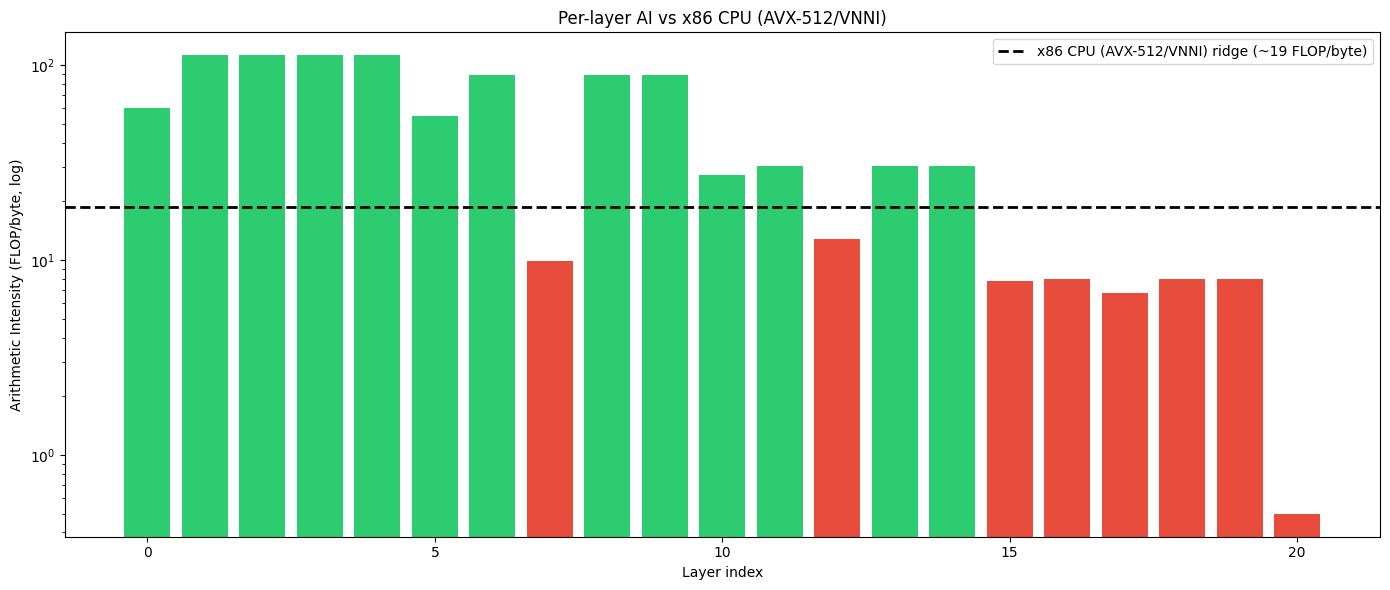

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Per-layer AI vs x86 CPU (AVX-512/VNNI)'}, xlabel='Layer index', ylabel='Arithmetic Intensity (FLOP/byte, log)'>,
 {'compute_bound': 13, 'memory_bound': 8, 'total': 21})

In [66]:
plot_ai(layer_ai, target=TARGET)

In [21]:
prof = LayerProfiler(model, torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE))
prof.profile('speed')
prof.summary(top=10)

═══ Speed (slowest) ═══════════════════════════════════════
  conv1                                    Conv2d             0.149 ms (  7.2%)
  layer1.0.conv1                           Conv2d             0.126 ms (  6.1%)
  layer1.0.conv2                           Conv2d             0.118 ms (  5.7%)
  layer1.1.conv1                           Conv2d             0.116 ms (  5.6%)
  layer1.1.conv2                           Conv2d             0.116 ms (  5.6%)
  layer2.1.conv1                           Conv2d             0.106 ms (  5.1%)
  layer2.1.conv2                           Conv2d             0.105 ms (  5.1%)
  layer2.0.conv2                           Conv2d             0.104 ms (  5.0%)
  layer3.0.conv1                           Conv2d             0.091 ms (  4.4%)
  layer2.0.conv1                           Conv2d             0.089 ms (  4.3%)



### PRUNE IT
> 🔮 **Predict.** Before running: will the AI bars move? Will the latency?

In [69]:
model_pruned = copy.deepcopy(model)
prune(model_pruned, 30, IMAGE_SIZE)

Ignoring output layer: fc
Total ignored layers: 1


In [70]:
layer_ai = compute_per_layer_ai(model_pruned, input_shape=(1, 3, IMAGE_SIZE, IMAGE_SIZE))

   # Layer                                                OPs           Bytes      AI (OPs/byte)
-----------------------------------------------------------------------------------------------
   0 conv1                                         52,985,856         943,376              56.17
   1 layer1.0.conv1                                35,684,352         430,144              82.96
   2 layer1.0.conv2                                35,684,352         430,144              82.96
   3 layer1.1.conv1                                35,684,352         430,144              82.96
   4 layer1.1.conv2                                35,684,352         430,144              82.96
   5 layer2.0.conv1                                18,044,928         412,336              43.76
   6 layer2.0.conv2                                36,499,968         467,428              78.09
   7 layer2.0.downsample.0                          2,004,992         287,024               6.99
   8 layer2.1.conv1            

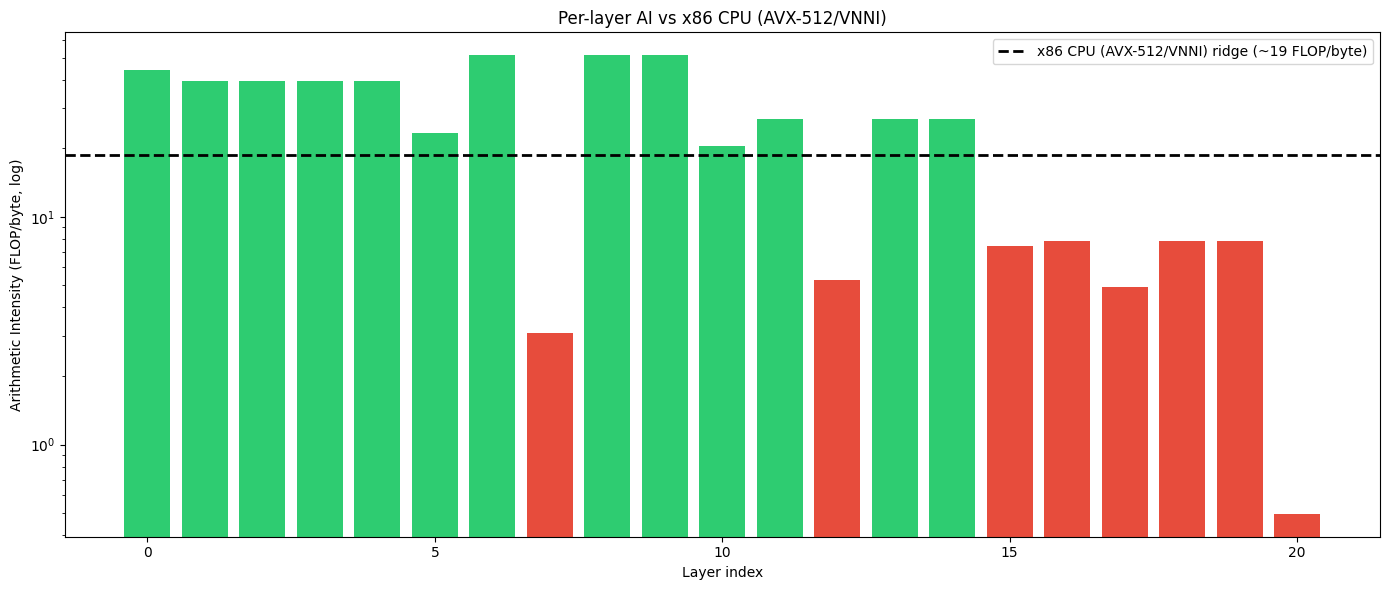

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Per-layer AI vs x86 CPU (AVX-512/VNNI)'}, xlabel='Layer index', ylabel='Arithmetic Intensity (FLOP/byte, log)'>,
 {'compute_bound': 13, 'memory_bound': 8, 'total': 21})

In [24]:
plot_ai(layer_ai,  target=TARGET)

In [25]:
prof = LayerProfiler(model_pruned, torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE))
prof.profile('speed')
prof.summary(top=10)

═══ Speed (slowest) ═══════════════════════════════════════
  conv1                                    Conv2d             0.096 ms ( 11.6%)
  layer1.0.conv1                           Conv2d             0.030 ms (  3.6%)
  layer1.1.conv1                           Conv2d             0.029 ms (  3.6%)
  layer1.0.conv2                           Conv2d             0.029 ms (  3.5%)
  maxpool                                  MaxPool2d          0.029 ms (  3.5%)
  layer2.1.conv1                           Conv2d             0.029 ms (  3.5%)
  layer2.1.conv2                           Conv2d             0.029 ms (  3.5%)
  layer1.1.conv2                           Conv2d             0.029 ms (  3.5%)
  layer2.0.conv2                           Conv2d             0.028 ms (  3.4%)
  layer3.1.conv1                           Conv2d             0.024 ms (  2.9%)



### QUANTIZE IT
> 🔮 **Predict.** Which way will the AI bars go, and how far?

In [26]:
qmodel = copy.deepcopy(model)
qmodel = quantize(qmodel)

/home/nathan/miniconda3/envs/dev/lib/python3.12/site-packages/torch/ao/quantization/observer.py:246: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


In [27]:
layer_ai = compute_per_layer_ai(qmodel, input_shape=(1, 3, IMAGE_SIZE, IMAGE_SIZE))

   # Layer                                                OPs           Bytes      AI (OPs/byte)
-----------------------------------------------------------------------------------------------
   0 conv1                                         77,070,336         320,704             240.32
   1 layer1.0.conv1                                75,497,472         167,936             449.56
   2 layer1.0.conv2                                75,497,472         167,936             449.56
   3 layer1.1.conv1                                75,497,472         167,936             449.56
   4 layer1.1.conv2                                75,497,472         167,936             449.56
   5 layer2.0.conv1                                37,748,736         172,032             219.43
   6 layer2.0.conv2                                75,497,472         212,992             354.46
   7 layer2.0.downsample.0                          4,194,304         106,496              39.38
   8 layer2.1.conv1            

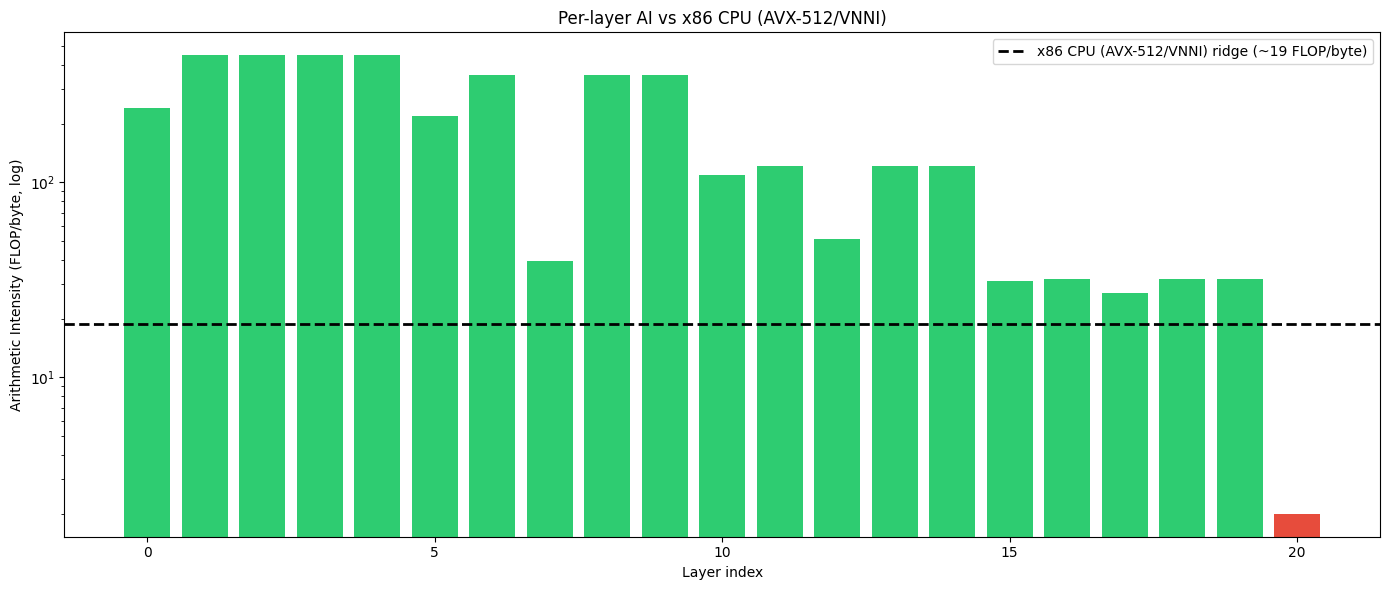

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Per-layer AI vs x86 CPU (AVX-512/VNNI)'}, xlabel='Layer index', ylabel='Arithmetic Intensity (FLOP/byte, log)'>,
 {'compute_bound': 20, 'memory_bound': 1, 'total': 21})

In [28]:
plot_ai(layer_ai, target=TARGET)

<br>

## 🔧 Things to try

1. **Predict**: apply pruning, do the AI bars move? Does latency move? Run: what moves, what doesn't, and why?
2. **Predict**: quantization, which way do the AI bars go, how far? Run: does size drop? Does latency drop on this hardware?
3. Which lever helped your memory-bound (red) layers? Which helped the compute-bound (green) ones?
4. Which layers benefit the most from pruning? And from quantization?

---

---
# 🎯 ACT 3 — EXECUTE
### *Keep the accuracy while compressing*

So far: pure performance. Now **accuracy enters**. Not all layers are equal (their *sensitivity*), and compressing without breaking the model takes **recovery**.

# 🛠️ HANDS-ON #3 — Where to cut (sensitivity)

> 🎯 **Goal**: accuracy enters. Measure each layer's *sensitivity*, cross it with the speed profile, and prune **per layer** instead of uniformly. The ideal layer to prune is **slow AND robust**.

### Load model

In [29]:
model = get_model(resnet18)
model.load_state_dict(torch.load('model_weights.pth'))
model.eval();

### Evaluate model

In [30]:
quick_acc(model)

0.9890625

> 🔮 **Predict.** Before running sensitivity: which layers do you bet are the most *fragile* (the ones NOT to prune)? The very first ones? The last ones?

In [31]:
sens = sensitivity(copy.deepcopy(model).to('cuda'), 64)

In [32]:
sens.summary(top=5)

════════════════════════════════════════════════════════════
Sensitivity Analysis: pruning @ 50%
════════════════════════════════════════════════════════════
  Baseline accuracy: 0.9891
  Layers analyzed: 20

  🔴 Most Sensitive (fragile):
     1. 0.0                            Δ=+0.6406  [group 0]
     2. 0.4.0.conv2                    Δ=+0.6406  [group 0]
     3. 0.4.1.conv2                    Δ=+0.6406  [group 0]
     4. 0.5.0.conv2                    Δ=+0.2125  [group 4]
     5. 0.5.0.downsample.0             Δ=+0.2125  [group 4]

  🟢 Most Robust (compressible):
     1. 0.7.1.conv1                    Δ=+0.0109  [group 11]
     2. 0.6.1.conv1                    Δ=+0.0125  [group 8]
     3. 0.7.0.conv1                    Δ=+0.0125  [group 9]
     4. 0.4.1.conv1                    Δ=+0.0172  [group 2]
     5. 0.4.0.conv1                    Δ=+0.0266  [group 1]


In [33]:
prof = LayerProfiler(copy.deepcopy(model), torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE))
prof.profile('speed', device='cpu')
prof.summary(top=15)

═══ Speed (slowest) ═══════════════════════════════════════
  0.0                                      Conv2d             0.192 ms (  5.1%)
  0.5.0.conv2                              Conv2d             0.187 ms (  5.0%)
  0.4.0.conv1                              Conv2d             0.185 ms (  4.9%)
  0.5.1.conv1                              Conv2d             0.184 ms (  4.9%)
  0.5.1.conv2                              Conv2d             0.183 ms (  4.9%)
  0.4.0.conv2                              Conv2d             0.176 ms (  4.7%)
  0.4.1.conv1                              Conv2d             0.175 ms (  4.7%)
  0.4.1.conv2                              Conv2d             0.174 ms (  4.6%)
  0.6.0.conv1                              Conv2d             0.164 ms (  4.4%)
  0.5.0.conv1                              Conv2d             0.147 ms (  3.9%)
  0.7.0.conv2                              Conv2d             0.141 ms (  3.7%)
  0.7.1.conv1                              Conv2d           

### Prune per layer
Pick a **robust** (green) layer from the list above, and prune it. Watch accuracy and the profile move.

In [34]:
targets = {'0.7.1.conv1': 10}

In [35]:
model_pruned = copy.deepcopy(model)
prune(model_pruned, targets, IMAGE_SIZE)

Ignoring output layer: 1.8
Total ignored layers: 1
Using per-layer pruning with 1 layer-specific ratios


In [36]:
quick_acc(model_pruned)

0.9890625

In [37]:
prof = LayerProfiler(model_pruned, torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE))
prof.profile('speed')
prof.summary(top=10)

═══ Speed (slowest) ═══════════════════════════════════════
  0.0                                      Conv2d             0.153 ms (  5.4%)
  0.5.0.conv2                              Conv2d             0.147 ms (  5.2%)
  0.4.0.conv1                              Conv2d             0.146 ms (  5.2%)
  0.5.1.conv1                              Conv2d             0.143 ms (  5.1%)
  0.5.1.conv2                              Conv2d             0.142 ms (  5.0%)
  0.4.0.conv2                              Conv2d             0.137 ms (  4.9%)
  0.4.1.conv1                              Conv2d             0.135 ms (  4.8%)
  0.4.1.conv2                              Conv2d             0.134 ms (  4.8%)
  0.6.0.conv1                              Conv2d             0.126 ms (  4.5%)
  0.7.0.conv2                              Conv2d             0.124 ms (  4.4%)



In [38]:
qmodel = copy.deepcopy(model)
qmodel = quantize(qmodel)

/home/nathan/miniconda3/envs/dev/lib/python3.12/site-packages/torch/ao/quantization/observer.py:246: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


In [39]:
prof = LayerProfiler(qmodel, torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE))
prof.profile('speed')
prof.summary(top=10)

═══ Speed (slowest) ═══════════════════════════════════════
  0.0                                      ConvReLU2d         0.114 ms (  7.2%)
  0.6.1.conv1                              ConvReLU2d         0.093 ms (  5.9%)
  0.6.0.conv2                              Conv2d             0.093 ms (  5.9%)
  0.6.1.conv2                              Conv2d             0.092 ms (  5.8%)
  0.5.1.conv1                              ConvReLU2d         0.091 ms (  5.7%)
  0.5.0.conv2                              Conv2d             0.090 ms (  5.7%)
  0.5.1.conv2                              Conv2d             0.089 ms (  5.6%)
  0.7.0.conv2                              Conv2d             0.089 ms (  5.6%)
  0.7.1.conv1                              ConvReLU2d         0.088 ms (  5.6%)
  0.4.0.conv1                              ConvReLU2d         0.088 ms (  5.6%)



<eval_with_key>.40:60: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at /pytorch/aten/src/ATen/native/quantized/cpu/TensorShape.cpp:167.)
  cat = torch.cat([quantize_per_tensor_30, _1_0_ap], 1);  quantize_per_tensor_30 = _1_0_ap = None


In [40]:
quick_acc(qmodel)

/home/nathan/miniconda3/envs/dev/lib/python3.12/site-packages/torch/_tensor.py:1654: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at /pytorch/aten/src/ATen/native/quantized/cpu/TensorShape.cpp:167.)
  ret = func(*args, **kwargs)


0.9890625

## 🔧 Things to try

1. **Predict**: before sensitivity, which layers do you bet are the most fragile? Run: are the first/last layers as fragile as you expected?
2. Cross the sensitivity list with the slowest layers from the profiler: is there a layer that is **both slow AND robust**? (the sweet spot)
3. Now try to update pruning target with several good pruning candidates. How does that affect latency and accuracy ?
4. Which layers benefit the most from pruning? And from quantization?

<br>

---
# 🏆 THE ARENA — compression competition

> 🎯 **Goal**: compose everything you learned to get **furthest left** (fastest) while staying **above the accuracy floor: 95%**. Below it = disqualified, no matter how fast.

> 🔧 **New this round: recovery.** Pruning all at once breaks accuracy. Pruning *gradually during training* (a schedule), then **QAT**, brings it back. You start from the trained model and your sensitivity from HO#3: now you **spend** them.

### 📋 Your playbook (fill in as you go)

| Step | Latency (ms) | Accuracy | Cumulative speedup |
|---|---|---|---|
| Baseline | | | 1.0x |
| + pruning (schedule) | | | |
| + QAT | | | |
| **Final** | | | |

In [41]:
model = get_model(resnet18)
model.load_state_dict(torch.load('model_weights.pth'))

learn = Learner(dls, model)

In [42]:
quick_acc(learn.model)

0.9890625

In [43]:
demo_benchmark(learn.model, IMAGE_SIZE)

═══ Size ════════════════════════════════════
  Disk:   44.74 MiB
  Params: 11.70M
═══ Speed ═══════════════════════════════════
  cpu: 10.74 ms  │  93.1 inf/s  │  p99: 10.75 ms
═══ Compute ═════════════════════════════════
  MACs: 596.0 M


### Sensitivity recap — choose where to spend your budget
(Same as HO#3; we just re-read it to pick which layers to prune.)

In [44]:
sens = sensitivity(copy.deepcopy(learn.model).to('cuda'), 64)

In [45]:
sens.summary(top=10)

════════════════════════════════════════════════════════════
Sensitivity Analysis: pruning @ 50%
════════════════════════════════════════════════════════════
  Baseline accuracy: 0.9891
  Layers analyzed: 20

  🔴 Most Sensitive (fragile):
     1. 0.0                            Δ=+0.6406  [group 0]
     2. 0.4.0.conv2                    Δ=+0.6406  [group 0]
     3. 0.4.1.conv2                    Δ=+0.6406  [group 0]
     4. 0.5.0.conv2                    Δ=+0.2125  [group 4]
     5. 0.5.0.downsample.0             Δ=+0.2125  [group 4]
     6. 0.5.1.conv2                    Δ=+0.2125  [group 4]
     7. 0.5.0.conv1                    Δ=+0.2000  [group 3]
     8. 0.6.0.conv2                    Δ=+0.1891  [group 7]
     9. 0.6.0.downsample.0             Δ=+0.1891  [group 7]
     10. 0.6.1.conv2                    Δ=+0.1891  [group 7]

  🟢 Most Robust (compressible):
     1. 0.7.1.conv1                    Δ=+0.0109  [group 11]
     2. 0.6.1.conv1                    Δ=+0.0125  [group 8]
     3

In [46]:
prof = LayerProfiler(copy.deepcopy(learn.model), torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE))
prof.profile('speed', device='cpu')
prof.summary(top=10)

═══ Speed (slowest) ═══════════════════════════════════════
  0.0                                      Conv2d             0.197 ms (  5.2%)
  0.5.0.conv2                              Conv2d             0.187 ms (  4.9%)
  0.4.0.conv1                              Conv2d             0.184 ms (  4.8%)
  0.5.1.conv1                              Conv2d             0.183 ms (  4.8%)
  0.5.1.conv2                              Conv2d             0.180 ms (  4.7%)
  0.4.1.conv1                              Conv2d             0.176 ms (  4.6%)
  0.4.0.conv2                              Conv2d             0.176 ms (  4.6%)
  0.4.1.conv2                              Conv2d             0.173 ms (  4.6%)
  0.6.0.conv1                              Conv2d             0.171 ms (  4.5%)
  0.5.0.conv1                              Conv2d             0.153 ms (  4.0%)



## Pruning-aware training

The fastest way to give accuracy back after pruning: don't remove everything at once. **Prune gradually during training** so the network re-adapts as channels disappear. Same final sparsity as before, far less accuracy lost.

In [47]:
# 👉 EXAMPLE, tune during your run. Strategy: prune the ROBUST (green) layers,
#    NOT the fragile ones. Spend the budget where accuracy barely moves.
targets = {'0.7.1.conv1': 20,
           '0.4.1.conv1': 20,
           '0.6.1.conv1': 20,
           '0.7.0.conv1': 20}

In [48]:
cbs = PruneCB(pruning_ratio=targets)

In [49]:
learn.fit(5, cbs=[cbs])

Ignoring output layer: 1.8
Total ignored layers: 1
Using per-layer pruning with 4 layer-specific ratios


epoch,train_loss,valid_loss,time
0,0.208448,0.140706,00:03
1,0.143979,0.118784,00:03
2,0.098642,0.124765,00:03
3,0.107812,0.157532,00:03
4,0.103520,0.195619,00:03


Pruning 4 layers to per-layer targets (epoch 0)
Pruning 4 layers to per-layer targets (epoch 1)
Pruning 4 layers to per-layer targets (epoch 2)
Pruning 4 layers to per-layer targets (epoch 3)
Pruning 4 layers to per-layer targets (epoch 4)


In [50]:
demo_benchmark(learn.model, IMAGE_SIZE)

═══ Size ════════════════════════════════════
  Disk:   37.43 MiB
  Params: 9.79M
═══ Speed ═══════════════════════════════════
  cpu: 10.09 ms  │  99.1 inf/s  │  p99: 10.11 ms
═══ Compute ═════════════════════════════════
  MACs: 538.6 M


## QAT

Earlier we quantized *after* training (PTQ). **Quantization-aware training** simulates INT8 rounding *during* training, so the model learns weights that survive quantization: better accuracy than PTQ at the same INT8 size.

In [51]:
learn.fit(3, cbs=[QuantizeCallback()])

/home/nathan/miniconda3/envs/dev/lib/python3.12/site-packages/torch/ao/quantization/observer.py:246: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


epoch,train_loss,valid_loss,time
0,0.072363,0.139438,00:03
1,0.059404,0.105246,00:03
2,0.069453,0.125406,00:03


In [52]:
demo_benchmark(learn.model, IMAGE_SIZE)

<eval_with_key>.61:60: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at /pytorch/aten/src/ATen/native/quantized/cpu/TensorShape.cpp:167.)
  cat = torch.cat([quantize_per_tensor_30, _1_0_ap], 1);  quantize_per_tensor_30 = _1_0_ap = None


═══ Size ════════════════════════════════════
  Disk:   9.49 MiB
  Params: 3.07K
═══ Speed ═══════════════════════════════════
  cpu: 4.35 ms  │  229.8 inf/s  │  p99: 4.38 ms
═══ Compute ═════════════════════════════════
  MACs: 0.0 M


# 🏁 Get Score
Report your result in the playbook above, then shout your speedup for the leaderboard.

In [53]:
score_model(learn.model)

/home/nathan/miniconda3/envs/dev/lib/python3.12/site-packages/torch/_tensor.py:1654: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at /pytorch/aten/src/ATen/native/quantized/cpu/TensorShape.cpp:167.)
  ret = func(*args, **kwargs)


(5.007895307540894, 0.959375)

<br>

---
# 🎬 Wrap-up

## What you did today
- **Act 1**: you measured *which force* slows your model (compute / memory / overhead), never read off the FLOPs.
- **Act 2**: you learned what each lever buys, and that the right one **depends on model × hardware**.
- **Act 3**: you recovered accuracy and composed a winning recipe.

> And you felt the tedium: **per layer × per technique × per target**, by hand. It never ends. *That is exactly what FasterRecipes automates.*

## The FasterAI ecosystem (open source)
- **FasterAI** (`pip install fasterai`): pruning, sparsification, quantization, distillation, sensitivity. https://github.com/FasterAI-Labs/fasterai
- **FasterBench** (`pip install fasterbench`): size / speed / compute / memory / energy, per-layer profiling. https://github.com/FasterAI-Labs/fasterbench

## Coming soon: FasterRecipes
Everything you did by hand (technique, granularity, schedule, sparsity per layer, for a target) automated:

```python
from fasterrecipes import optimize, Constraints
result = optimize(model, sample, target='nvidia-a100',
                  data=dls, constraints=Constraints(min_accuracy=90))
result.summary(); result.export()
```

**14 hardware profiles** (NVIDIA A100/H100/T4/Jetson, Intel, AMD, ARM, Apple).

## What's next?
Today: a toy model, on a shared T4. The real question is **your** model, on **your** hardware, under **your** accuracy contract, re-measured on your real device. That's the **Design Partner Program**.

👉 **Come find me at the break**: 15 minutes of qualification today beats 3 emails later.

**Nathan Hubens**: nh@fasterai-labs.com · https://fasterai-labs.com · https://github.com/FasterAI-Labs